# Google Drive Integration



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Importing Libraries

In [ ]:
import os
import numpy as np
import librosa
import random
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Feature Extraction from Audio Files

In [ ]:
def extract_features(file_path, augment=False):
    try:
        audio, sr = librosa.load(file_path, sr=22050, duration=5)

        if augment:
            if random.random() > 0.5:
                shift = np.random.randint(500)
                audio = np.roll(audio, shift)

            if random.random() > 0.5:
                noise = np.random.randn(len(audio)) * 0.005
                audio = audio + noise

        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=40, n_fft=2048, n_mels=40, fmax=sr//2 - 100)
        delta_mfcc = librosa.feature.delta(mfccs)
        delta2_mfcc = librosa.feature.delta(mfccs, order=2)
        features = np.concatenate((mfccs, delta_mfcc, delta2_mfcc), axis=0)

        return np.mean(features.T, axis=0)
    except:
        return None

# Dataset Preparation and Preprocessing

In [ ]:
data_folder = '/content/drive/MyDrive/dataset'
features, labels = [], []

for root, _, files in os.walk(data_folder):
    for file_name in files:
        if file_name.endswith(".wav") and not file_name.startswith("._"):
            file_path = os.path.join(root, file_name)
            label = os.path.basename(root)

            mfcc_features = extract_features(file_path)
            if mfcc_features is not None:
                features.append(mfcc_features)
                labels.append(label)

            mfcc_features_aug = extract_features(file_path, augment=True)
            if mfcc_features_aug is not None:
                features.append(mfcc_features_aug)
                labels.append(label)

features = np.array(features)
labels = np.array(labels)

# Scaling the features
scaler = StandardScaler()
features = scaler.fit_transform(features)

# Encoding labels
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)
labels_encoded = to_categorical(labels_encoded)

# Reshaping features
features_reshaped = features[..., np.newaxis, np.newaxis]

# Splitting dataset
X_train, X_test, y_train, y_test = train_test_split(features_reshaped, labels_encoded, test_size=0.15, random_state=42)

# Model Architecture and Training

In [ ]:
model_lenet = Sequential([
    Input(shape=(features_reshaped.shape[1], features_reshaped.shape[2], 1)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2), strides=(1, 1), padding='same'),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2), strides=(1, 1), padding='same'),

    Conv2D(256, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2), strides=(1, 1), padding='same'),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.4),

    Dense(256, activation='relu'),
    Dropout(0.4),

    Dense(len(label_encoder.classes_), activation='softmax')
])

# Compiling the model with a lower learning rate
model_lenet.compile(optimizer=Adam(learning_rate=0.0002), loss='categorical_crossentropy', metrics=['accuracy'])

# Training the model with 150 epochs
history = model_lenet.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_test, y_test))

Epoch 1/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 35s 416ms/step - accuracy: 0.4777 - loss: 2.5133 - val_accuracy: 0.2228 - val_loss: 2.1659
Epoch 2/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 39s 401ms/step - accuracy: 0.8030 - loss: 1.0762 - val_accuracy: 0.3861 - val_loss: 2.7769
Epoch 3/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 400ms/step - accuracy: 0.8863 - loss: 0.4696 - val_accuracy: 0.3267 - val_loss: 2.1527
Epoch 4/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 401ms/step - accuracy: 0.9076 - loss: 0.3905 - val_accuracy: 0.3861 - val_loss: 1.8952
Epoch 5/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 40s 394ms/step - accuracy: 0.9537 - loss: 0.1790 - val_accuracy: 0.8069 - val_loss: 0.8719
Epoch 6/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 394ms/step - accuracy: 0.9699 - loss: 0.1619 - val_accuracy: 0.9109 - val_loss: 0.3853
Epoch 7/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 29s 399ms/step - accuracy: 0.9677 - loss: 0.1023 - val_accuracy: 0.9554 - val_loss: 0.1888
Epoch 8/100
72/72 ━━━━━━━━━━━━━━━━━━━━ 41s 395ms/step - accuracy: 0.9772 - loss: 0.0680 - 

# Model Evaluation and Performance Metrics

Training Accuracy: 100.00%
Test Accuracy: 99.50%
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step


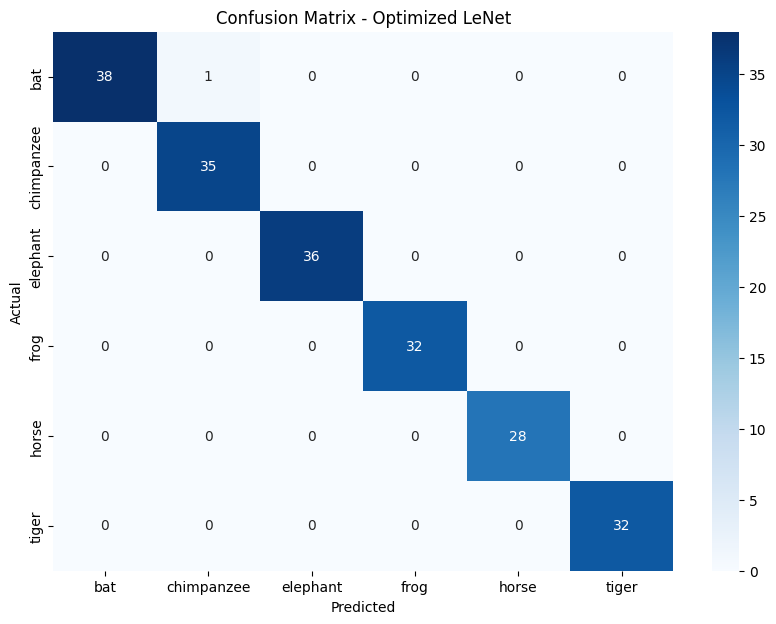

In [ ]:
# Evaluating model accuracy
train_accuracy = model_lenet.evaluate(X_train, y_train, verbose=0)[1] * 100
test_accuracy = model_lenet.evaluate(X_test, y_test, verbose=0)[1] * 100

print(f"Training Accuracy: {train_accuracy:.2f}%")
print(f"Test Accuracy: {test_accuracy:.2f}%")

# Predictions & Confusion Matrix
y_pred = model_lenet.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

conf_matrix = confusion_matrix(y_test_classes, y_pred_classes)

plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix - Optimized LeNet")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Model Performance Analysis: Class-wise & Overall Metrics

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

              precision    recall  f1-score   support

         bat       0.97      1.00      0.99        39
  chimpanzee       0.95      1.00      0.97        35
    elephant       1.00      0.97      0.99        36
        frog       0.97      0.91      0.94        32
       horse       1.00      0.96      0.98        28
       tiger       0.97      1.00      0.98        32

    accuracy                           0.98       202
   macro avg       0.98      0.97      0.97       202
weighted avg       0.98      0.98      0.98       202



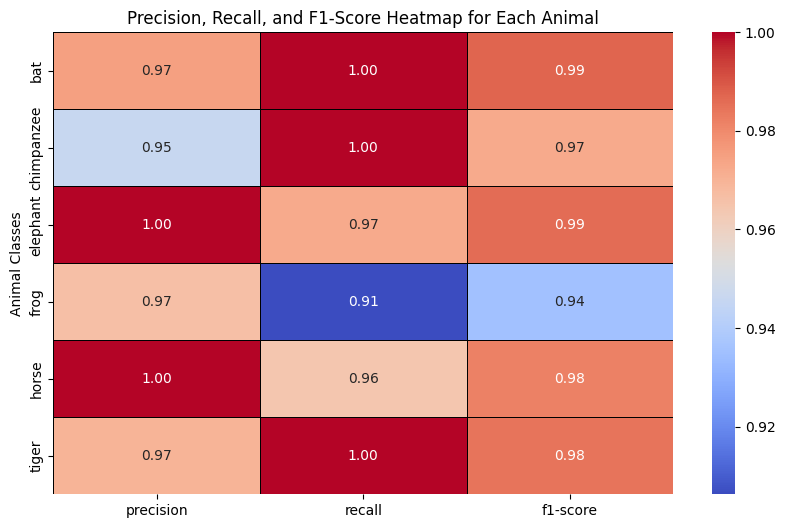

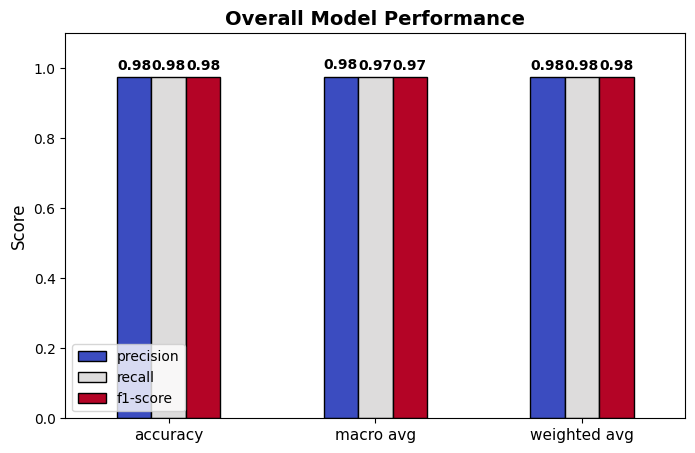

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import numpy as np

# Generate classification report
report = classification_report(y_true, y_pred, output_dict=True, target_names=label_encoder.classes_)
df = pd.DataFrame(report).T  # Convert to DataFrame

# ----- Plot 1: Heatmap for Precision, Recall, and F1-Score -----
plt.figure(figsize=(10, 6))
sns.heatmap(df.iloc[:-3, :-1][['precision', 'recall', 'f1-score']], annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, linecolor='black')
plt.title("Precision, Recall, and F1-Score Heatmap for Each Animal")
plt.ylabel("Animal Classes")
plt.show()

# ----- Plot 2: Cleaned Bar Chart for Overall Performance -----
overall_metrics = df.iloc[-3:, :-1]  # Selecting accuracy, macro avg, and weighted avg

# Set up figure
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["royalblue", "tomato", "seagreen"]
bars = overall_metrics.plot(kind="bar", colormap="coolwarm", legend=True, ax=ax, edgecolor="black")

# Set labels and title
ax.set_title("Overall Model Performance", fontsize=14, fontweight='bold')
ax.set_ylabel("Score", fontsize=12)
ax.set_ylim(0, 1.1)  # Slightly above 1 for better spacing
ax.set_xticklabels(overall_metrics.index, rotation=0, fontsize=11)

# Add value labels ABOVE the bars
for bar in bars.containers:
    ax.bar_label(bar, fmt="%.2f", label_type="edge", padding=3, fontsize=10, fontweight='bold')

plt.show()

# Training vs Validation Accuracy Graph

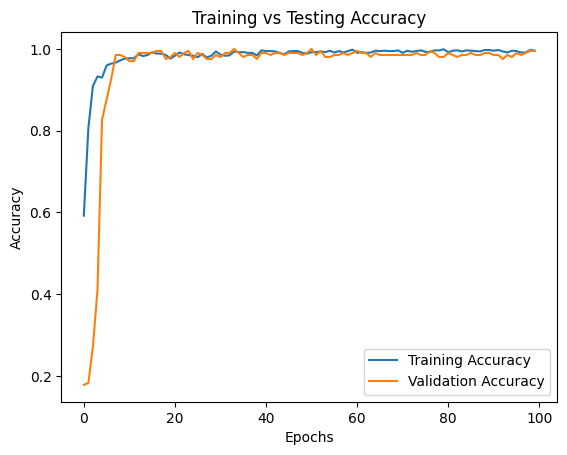

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy')
plt.legend()
plt.show()

# Model Evaluation Metrics

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Predict classes for the test set
# Change 'model' to 'model_lenet' to use the correct model variable
y_pred_probs = model_lenet.predict(X_test)  # Get predicted probabilities
y_pred = np.argmax(y_pred_probs, axis=1)  # Convert probabilities to class labels
y_true = np.argmax(y_test, axis=1)  # Convert one-hot encoded labels to class labels

# Calculate evaluation metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

# Print the results
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-score: {f1:.4f}')

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 148ms/step
Accuracy: 0.9752
Precision: 0.9757
Recall: 0.9752
F1-score: 0.9751


# Animal Sound Prediction Function

In [ ]:
def predict_animal(audio_file_path):
    features = extract_features(audio_file_path)
    if features is not None:
        features = scaler.transform([features])[..., np.newaxis, np.newaxis]  # Normalize and reshape
        predicted_label = label_encoder.inverse_transform([np.argmax(model.predict(features, verbose=0))])[0]
        print(f"Predicted Animal: {predicted_label}")
    else:
        print("Error extracting features.")

# Test prediction
predict_animal('/content/drive/MyDrive/dataset/bat/bat_102.wav')

Predicted Animal: bat


#Animal Sound Prediction from External Audio Source

In [ ]:
# testing external audio
def predict_animal(audio_file_path):
    features = extract_features(audio_file_path)
    if features is not None:
        features = scaler.transform([features])[..., np.newaxis, np.newaxis]
        predicted_label = label_encoder.inverse_transform([np.argmax(model_lenet.predict(features, verbose=0))])[0]
        print(f"Predicted Animal: {predicted_label}")
    else:
        print("Error extracting features.")

# Test prediction
predict_animal('/content/Elefant.wav')

Predicted Animal: elephant
